<a href="https://colab.research.google.com/github/NidhiSahu1234/Diabetes-Predictor/blob/main/DiabetesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTING THE DEPENDENCIES

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# DATA COLLECTION

In [7]:
diabetes_dataset = pd.read_csv(
    r"C:\Users\Nidhi\OneDrive\Desktop\DiaBeta-AI\ml\diabetes.csv"
)

In [8]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
diabetes_dataset.shape

(768, 9)

In [10]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
diabetes_dataset["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# **DATA PREPROCESSING**

DATA CLEANING

In [12]:
cols_with_zeros=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
diabetes_dataset[cols_with_zeros]=diabetes_dataset[cols_with_zeros].replace(0,np.nan)
for col in cols_with_zeros:
  diabetes_dataset[col].fillna(diabetes_dataset[col].median(),inplace=True)

C:\Users\Nidhi\AppData\Local\Temp\ipykernel_21856\2346680217.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  diabetes_dataset[col].fillna(diabetes_dataset[col].median(),inplace=True)
C:\Users\Nidhi\AppData\Local\Temp\ipykernel_21856\2346680217.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series t

SEPARATING DATA AND LABELS

In [14]:
print(diabetes_dataset.head())
print(diabetes_dataset.columns)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      NaN  33.6   
1            1     85.0           66.0           29.0      NaN  26.6   
2            8    183.0           64.0            NaN      NaN  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')


DATA STANDARDISATION

In [17]:
X = diabetes_dataset.drop(columns=["Outcome"])
Y = diabetes_dataset["Outcome"]

print(X.shape)
print(Y.shape)

(768, 8)
(768,)


In [18]:
scaler=StandardScaler()
standardized_data=scaler.fit_transform(X)
print(standardized_data)

[[ 0.63994726  0.86228736 -0.03274557 ...  0.16509656  0.46849198
   1.4259954 ]
 [-0.84488505 -1.20222881 -0.51764464 ... -0.84640379 -0.36506078
  -0.19067191]
 [ 1.23388019  2.0092408  -0.67927766 ... -1.32325395  0.60439732
  -0.10558415]
 ...
 [ 0.3429808  -0.02250528 -0.03274557 ... -0.90420381 -0.68519336
  -0.27575966]
 [-0.84488505  0.14134521 -1.00254371 ... -0.34065362 -0.37110101
   1.17073215]
 [-0.84488505 -0.94006803 -0.19437859 ... -0.2973036  -0.47378505
  -0.87137393]]


In [19]:
X=standardized_data
Y=diabetes_dataset["Outcome"]
print(X)
print(Y)

[[ 0.63994726  0.86228736 -0.03274557 ...  0.16509656  0.46849198
   1.4259954 ]
 [-0.84488505 -1.20222881 -0.51764464 ... -0.84640379 -0.36506078
  -0.19067191]
 [ 1.23388019  2.0092408  -0.67927766 ... -1.32325395  0.60439732
  -0.10558415]
 ...
 [ 0.3429808  -0.02250528 -0.03274557 ... -0.90420381 -0.68519336
  -0.27575966]
 [-0.84488505  0.14134521 -1.00254371 ... -0.34065362 -0.37110101
   1.17073215]
 [-0.84488505 -0.94006803 -0.19437859 ... -0.2973036  -0.47378505
  -0.87137393]]
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


TRAIN TEST SPLIT

In [20]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)
print(X.shape,X_train.shape,X_test.shape)

(768, 8) (614, 8) (154, 8)


# TRAINING THE MODEL

In [36]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    min_samples_leaf=4,
    random_state=42
)
model.fit(X_train,Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

# **MODEL EVALUATION**

ACCURACY SCORE ON TRAINED DATA

In [22]:
X_train_accuracy=model.predict(X_train)
predictions_made=len(X_train_accuracy)
print(predictions_made)

training_data_accuracy=accuracy_score(X_train_accuracy,Y_train)

614


In [23]:
print("Accuracy score of the training data:",training_data_accuracy)

Accuracy score of the training data: 0.8876221498371335


In [24]:
from sklearn.metrics import recall_score
risk_detection_recall = recall_score(Y_train, X_train_accuracy)
print("Risk Detection Recall:", risk_detection_recall)

Risk Detection Recall: 0.9205607476635514


ACCURACY SCORE ON TEST DATA

In [25]:
X_test_accuracy=model.predict(X_test)
predictions_made=len(X_test_accuracy)
print(predictions_made)
test_data_accuracy=accuracy_score(X_test_accuracy,Y_test)

154


In [26]:
print("Accuracy score of the test data:",test_data_accuracy)

Accuracy score of the test data: 0.7532467532467533


MAKING PREDICTIVE SYSTEM

In [27]:
input_data = (5,166,72,19,175,25.8,0.587,51)

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

std_data = scaler.transform(input_data_reshaped)
print(std_data)

prediction = model.predict(std_data)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[[ 0.3429808   1.45214913 -0.03274557 -0.97001371  0.163977   -0.96200383
   0.34768723  1.51108316]]
[1]
The person is diabetic


C:\Users\Nidhi\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# RESULT VISUALISATION

CONFUSION MATRIX

In [28]:
print("Confusion Matrix:")
print(confusion_matrix(Y_test, X_test_accuracy))

print("\nClassification Report:")
print(classification_report(Y_test, X_test_accuracy))

print("Accuracy Score:", accuracy_score(Y_test, X_test_accuracy))

Confusion Matrix:
[[80 20]
 [18 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       100
           1       0.64      0.67      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.76      0.75      0.75       154

Accuracy Score: 0.7532467532467533


Matplotlib is building the font cache; this may take a moment.


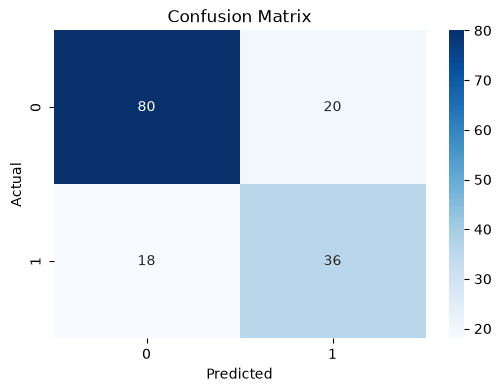

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, X_test_accuracy)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

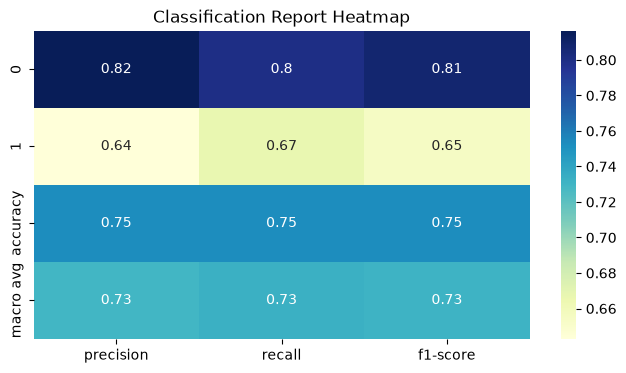

In [30]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(Y_test, X_test_accuracy, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu")
plt.title("Classification Report Heatmap")
plt.show()

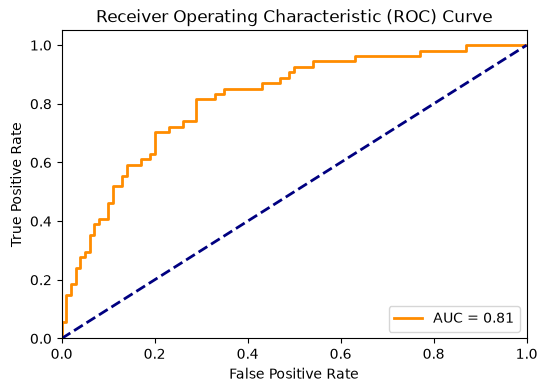

In [31]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

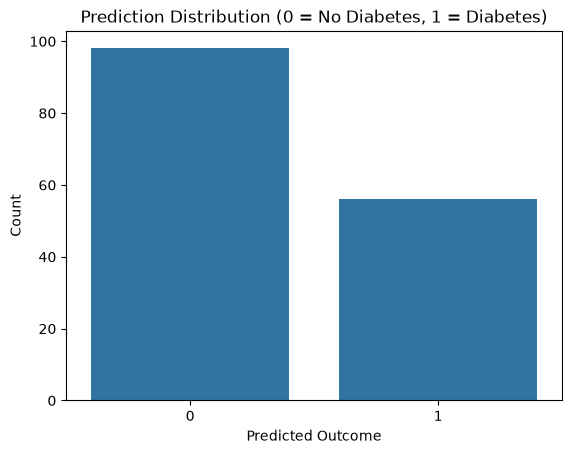

In [32]:
sns.countplot(x=X_test_accuracy)
plt.title("Prediction Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.xlabel("Predicted Outcome")
plt.ylabel("Count")
plt.show()

In [34]:
diabetes_dataset["Outcome Label"]=diabetes_dataset["Outcome"].map({0:"No Diabetes",1:"Diabetes"})
diabetes_dataset["Prediction"]=model.predict(X)
diabetes_dataset["Prediction Label"]=diabetes_dataset["Prediction"].map({0:"No Diabetes",1:"Diabetes"})
diabetes_dataset.to_csv("powerbi_ready.csv", index=False)


In [37]:
import joblib

joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
